# Metro Interstate Traffic Volume
## Ensemble Model Comparison: Random Forest vs AdaBoost vs XGBoost

**Dataset:** UCI ML Repository -- Metro Interstate Traffic Volume (ID 492)  
**Task:** Regression -- predict hourly traffic volume on I-94 between Minneapolis and St Paul, MN  
**Models compared:** Random Forest, AdaBoost, XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

## 1. Load and Initial Inspection

In [2]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
5,NaN,291.72,0.0,0.0,1,Clear,sky is clear,2012-10-02 14:00:00,5181
6,NaN,293.17,0.0,0.0,1,Clear,sky is clear,2012-10-02 15:00:00,5584
7,NaN,293.86,0.0,0.0,1,Clear,sky is clear,2012-10-02 16:00:00,6015
8,NaN,294.14,0.0,0.0,20,Clouds,few clouds,2012-10-02 17:00:00,5791
9,NaN,293.10,0.0,0.0,20,Clouds,few clouds,2012-10-02 18:00:00,4770


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


In [4]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [5]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

The dataset has 48,204 hourly records from October 2012 to September 2018. Features are a mix of weather conditions, a holiday flag, and a timestamp. The target is `traffic_volume` (integer count of vehicles per hour).

Key things to check before trusting the data:
- `holiday` has 48,143 nulls -- but this is because only the first hour of each holiday day is labelled. The other 23 hours are null. This needs to be fixed to be useful.
- `temp` minimum is 0.0 Kelvin, which is physically impossible (absolute zero has never been observed on Earth).
- `rain_1h` max is 9831.3 mm/hr, far beyond any recorded rainfall on Earth (world record is ~305 mm/hr). This is a sensor error.
- 17 duplicate rows need to be removed.

## 2. Data Cleaning

In [6]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. Now: {len(df)}")

Dropped 17 duplicate rows. Now: 48187


In [7]:
# Fix 0 Kelvin temperature -- replace with NaN then interpolate from neighbours
# These cluster in Jan-Feb 2014 and appear to be sensor outages
zero_temp = (df['temp'] == 0).sum()
print(f"Rows with temp = 0 K: {zero_temp}")
df.loc[df['temp'] == 0, 'temp'] = np.nan
df['temp'] = df['temp'].interpolate(method='linear')
print(f"Remaining nulls in temp: {df['temp'].isnull().sum()}")

Rows with temp = 0 K: 10
Remaining nulls in temp: 0


In [8]:
# Fix extreme rain outlier (9831.3 mm/hr is impossible)
print(f"Rain values > 100 mm/hr: {(df['rain_1h'] > 100).sum()}")
df.loc[df['rain_1h'] > 100, 'rain_1h'] = np.nan
df['rain_1h'] = df['rain_1h'].fillna(df['rain_1h'].median())
print(f"Max rain after fix: {df['rain_1h'].max():.2f} mm/hr")

Rain values > 100 mm/hr: 1
Max rain after fix: 55.63 mm/hr


In [9]:
# Fix holiday column -- only first hour of each holiday day is labelled.
# Forward-fill within each calendar date so all 24 hours share the same label.
df['date_only'] = df['date_time'].dt.date
df['holiday'] = df.groupby('date_only')['holiday'].transform(
    lambda x: x.ffill().bfill()
)
df['holiday'] = df['holiday'].fillna('None')
print("Holiday value counts:")
print(df['holiday'].value_counts())

Holiday value counts:
holiday
None                         46778
Labor Day                      157
Washingtons Birthday           136
Thanksgiving Day               135
Memorial Day                   134
Christmas Day                  131
New Years Day                  131
Independence Day               126
Veterans Day                   120
State Fair                     120
Columbus Day                   112
Martin Luther King Jr Day      107
Name: count, dtype: int64


In [10]:
# Two rows with traffic_volume = 0 -- likely sensor dropout, not genuine zero traffic
print("Zero traffic rows:")
print(df[df['traffic_volume'] == 0])
df = df[df['traffic_volume'] > 0].reset_index(drop=True)
print(f"Rows after removing zero-traffic: {len(df)}")

Zero traffic rows:
      holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
25184    None  296.68      0.0      0.0          40         Rain   
25189    None  295.90      0.0      0.0          90         Haze   

      weather_description           date_time  traffic_volume   date_only  
25184          light rain 2016-07-23 18:00:00               0  2016-07-23  
25189                haze 2016-07-23 23:00:00               0  2016-07-23  
Rows after removing zero-traffic: 48185


In [11]:
print("Final cleaned shape:", df.shape)
print("Any nulls remaining:", df.isnull().sum().sum())
df.describe()

Final cleaned shape: (48185, 10)
Any nulls remaining: 0


,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,48185.000000,48185.000000,48185.000000,48185.000000,48185,48185.000000
mean,281.257428,0.130363,0.000222,49.364802,2016-01-05 06:37:48.855452,3259.753429
min,243.390000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,1.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 07:00:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-10 20:00:00,3379.000000
75%,291.800000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,55.630000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,12.713817,1.003562,0.008169,39.015560,NaN,1986.884716


## 3. Feature Engineering

The timestamp is the richest source of signal in this dataset. Traffic on a road follows strong daily and weekly cycles that raw numeric features cannot capture on their own. We extract several time features from `date_time`.

The `holiday` column is a string -- we convert it to a binary is_holiday flag since the specific holiday name should not matter, only whether it is a holiday or not. Similarly, `weather_main` and `weather_description` get label-encoded.

In [12]:
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']       = df['date_time'].dt.month
df['year']        = df['date_time'].dt.year
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_holiday']  = (df['holiday'] != 'None').astype(int)

# Rush hour flag: 7-9am and 4-7pm on weekdays
df['is_rush'] = (
    (df['is_weekend'] == 0) &
    (df['hour'].isin([7, 8, 9, 16, 17, 18, 19]))
).astype(int)

# Cyclic encoding for hour and month -- prevents the model treating hour 23
# and hour 0 as far apart when they are actually adjacent
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Temperature in Celsius -- easier to reason about
df['temp_c'] = df['temp'] - 273.15

print("New feature columns added:")
new_cols = ['hour','day_of_week','month','year','is_weekend','is_holiday',
            'is_rush','hour_sin','hour_cos','month_sin','month_cos',
            'dow_sin','dow_cos','temp_c']
print(new_cols)

New feature columns added:
['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'is_rush', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temp_c']


In [13]:
# Encode categorical weather features
le_weather = LabelEncoder()
le_desc    = LabelEncoder()

df['weather_enc'] = le_weather.fit_transform(df['weather_main'])
df['desc_enc']    = le_desc.fit_transform(df['weather_description'])

print("Weather categories:", le_weather.classes_)

Weather categories: ['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']


In [14]:
# Final feature set
features = [
    'temp_c', 'rain_1h', 'snow_1h', 'clouds_all',
    'weather_enc', 'desc_enc',
    'hour', 'day_of_week', 'month', 'year',
    'is_weekend', 'is_holiday', 'is_rush',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos'
]

X = df[features]
y = df['traffic_volume']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (48185, 19)
Target shape: (48185,)


## 4. Exploratory Data Analysis

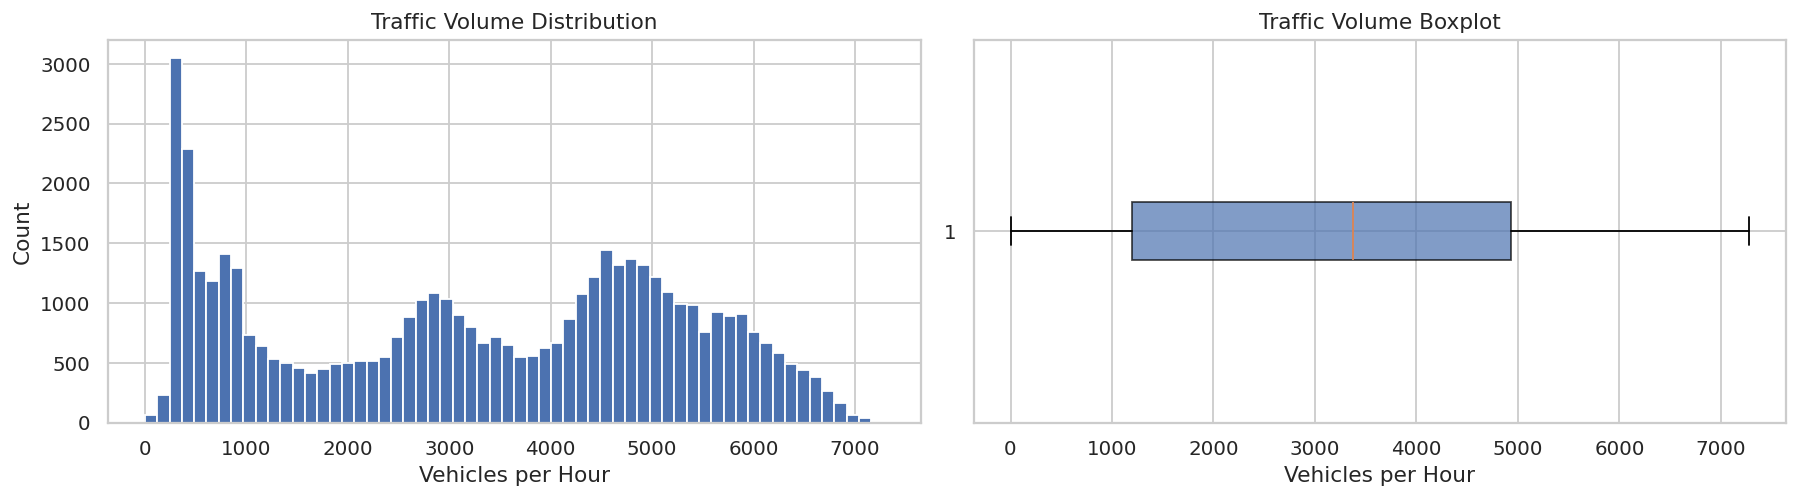

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Traffic Volume Distribution')
axes[0].set_xlabel('Vehicles per Hour')
axes[0].set_ylabel('Count')

axes[1].boxplot(y, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Traffic Volume Boxplot')
axes[1].set_xlabel('Vehicles per Hour')

plt.tight_layout()
plt.savefig('eda_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Traffic volume is roughly bimodal -- a cluster of low-volume hours (nights and early mornings) and a cluster of high-volume hours (daytime). This makes intuitive sense and tells us `hour` will be one of the most predictive features.

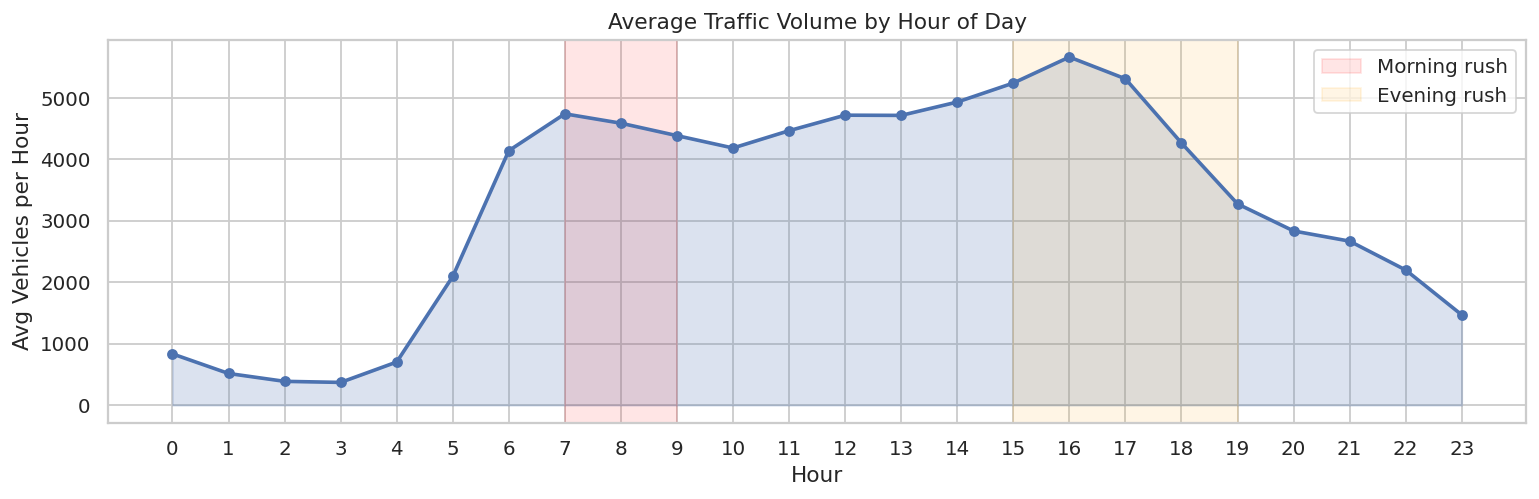

In [16]:
# Average traffic by hour of day
hourly = df.groupby('hour')['traffic_volume'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2, color='#4C72B0', markersize=5)
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color='#4C72B0')
ax.set_title('Average Traffic Volume by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Vehicles per Hour')
ax.set_xticks(range(24))
ax.axvspan(7, 9, alpha=0.1, color='red', label='Morning rush')
ax.axvspan(15, 19, alpha=0.1, color='orange', label='Evening rush')
ax.legend()
plt.tight_layout()
plt.savefig('eda_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

Classic double-peak rush hour pattern: morning peak around 7-8am and a larger evening peak around 4-5pm. Traffic drops to very low levels between midnight and 5am. This is the strongest pattern in the entire dataset.

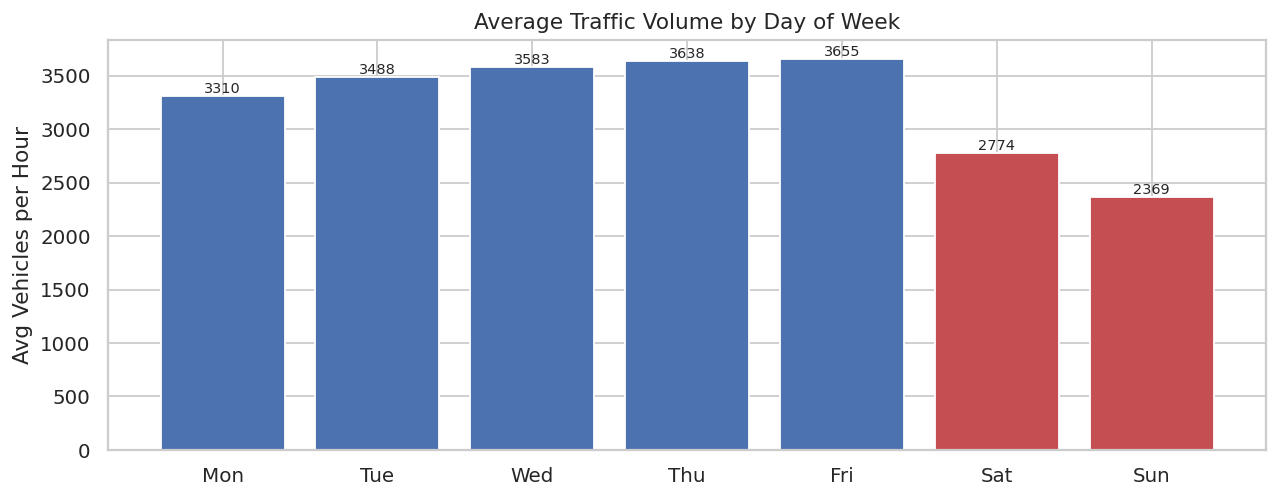

In [17]:
# By day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = df.groupby('day_of_week')['traffic_volume'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(day_names, dow_avg.values,
              color=['#4C72B0']*5 + ['#C44E52']*2, edgecolor='white')
ax.set_title('Average Traffic Volume by Day of Week')
ax.set_ylabel('Avg Vehicles per Hour')
for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, f'{val:.0f}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_dow.png', dpi=150, bbox_inches='tight')
plt.show()

Weekdays (Mon-Fri) have substantially higher average traffic than weekends. Saturday and Sunday show about 25-30% less traffic, which also confirms that `is_weekend` and `day_of_week` will carry significant predictive weight.

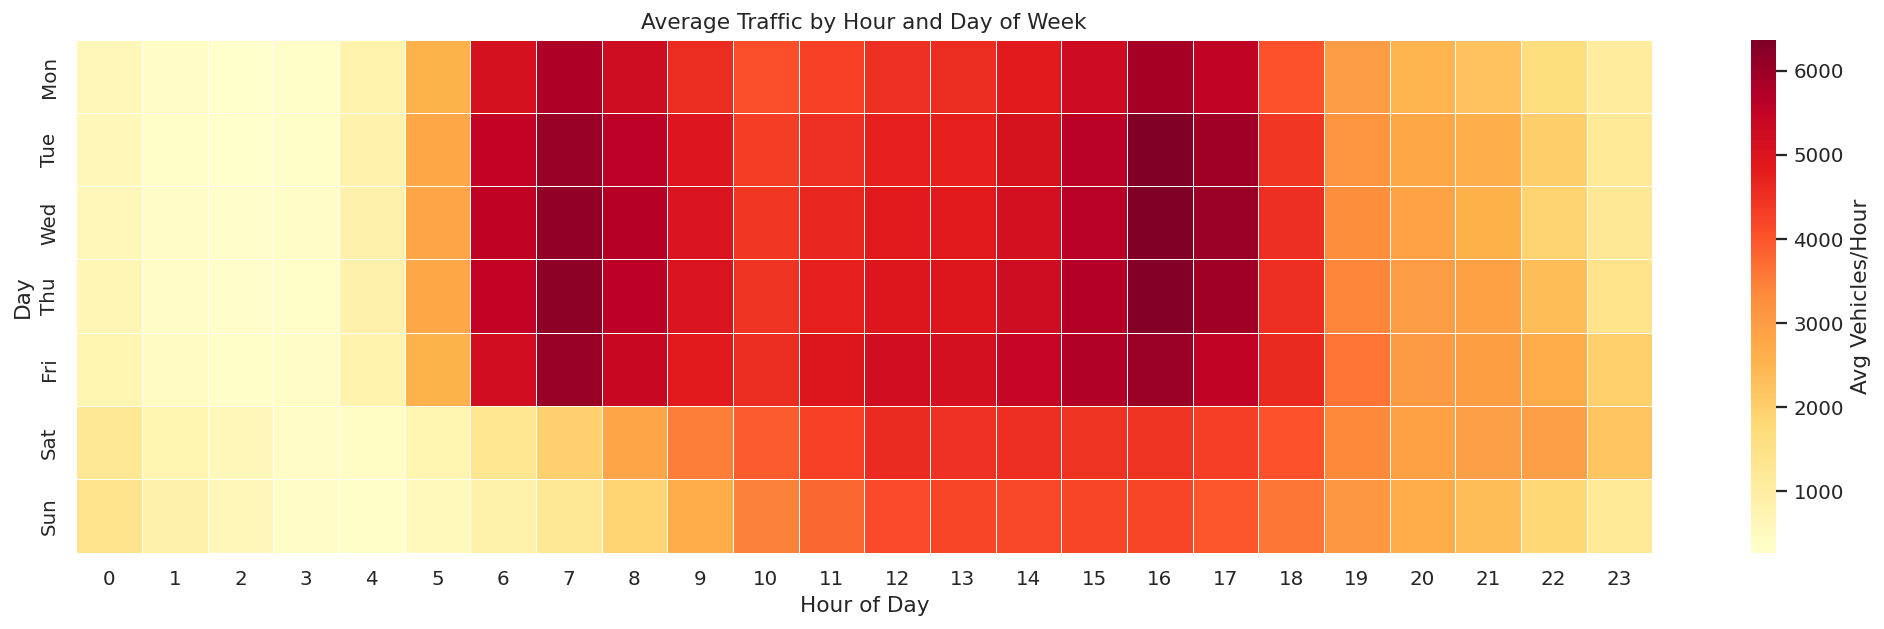

In [18]:
# Hour x day heatmap -- the interaction of these two is very informative
pivot = df.groupby(['day_of_week', 'hour'])['traffic_volume'].mean().unstack()
pivot.index = day_names

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Avg Vehicles/Hour'})
ax.set_title('Average Traffic by Hour and Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day')
plt.tight_layout()
plt.savefig('eda_heatmap_hourdow.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap shows the rush-hour effect is specific to weekdays. Saturday and Sunday have lower, flatter traffic throughout the day with no sharp peaks. The most extreme cells (dark red) are weekday 4-5pm -- this is the highest-traffic period of the week.

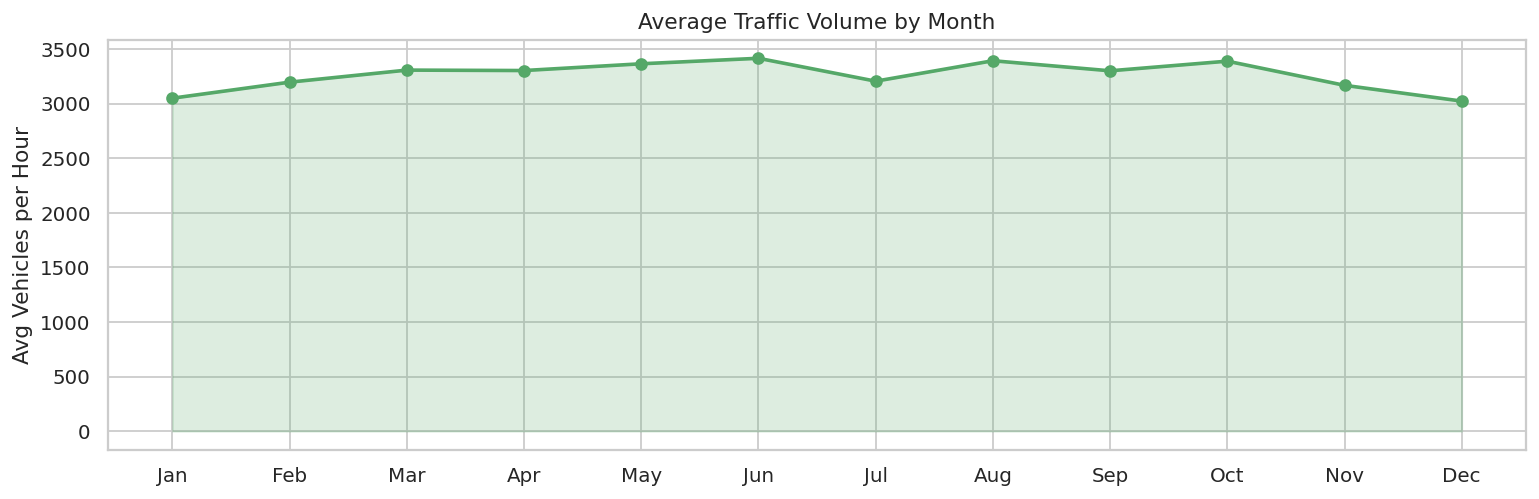

In [19]:
# Monthly trend
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month')['traffic_volume'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(month_names, monthly.values, marker='o', linewidth=2,
        color='#55A868', markersize=6)
ax.fill_between(range(12), monthly.values, alpha=0.2, color='#55A868')
ax.set_title('Average Traffic Volume by Month')
ax.set_ylabel('Avg Vehicles per Hour')
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
plt.tight_layout()
plt.savefig('eda_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

Traffic peaks in summer months (June-August) and dips in winter (December-February). This is likely a combination of weather effects and seasonal commuting behaviour. July is consistently the highest month, December the lowest.

                     mean  count
weather_main                    
Clouds        3617.989115  15158
Haze          3504.678440   1359
Rain          3318.490566   5671
Drizzle       3292.189560   1820
Smoke         3237.650000     20
Clear         3055.614465  13384
Snow          3016.321391   2875
Thunderstorm  2999.431752   1033
Mist          2933.343923   5949
Fog           2703.720395    912
Squall        2061.750000      4


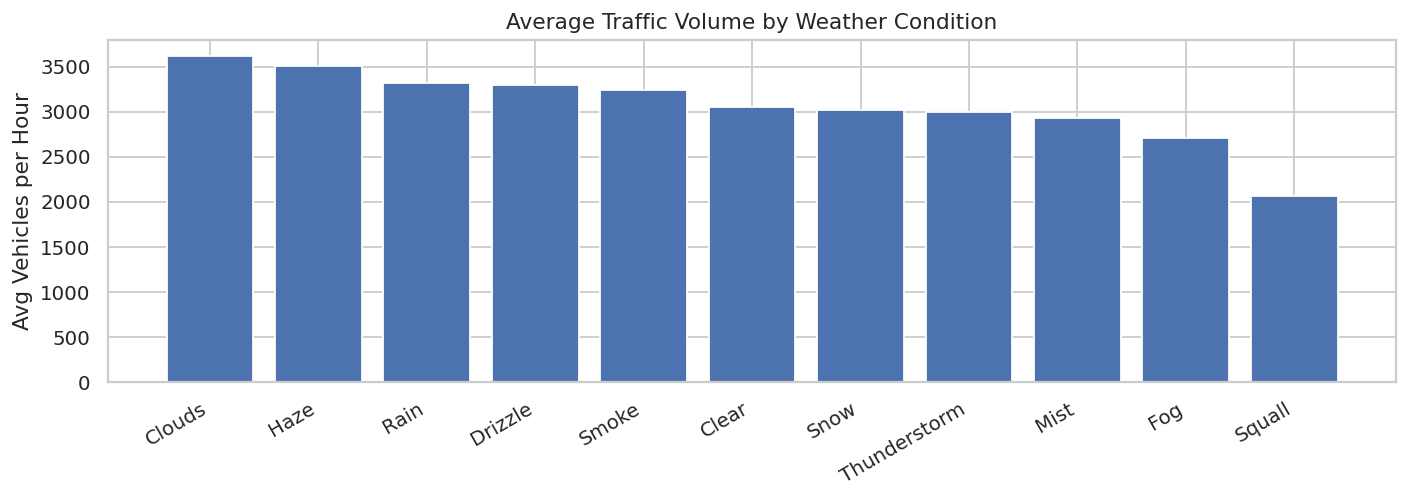

In [20]:
# Weather impact
weather_avg = df.groupby('weather_main')['traffic_volume'].agg(['mean','count']).sort_values('mean', ascending=False)
print(weather_avg)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(weather_avg.index, weather_avg['mean'], color='#4C72B0', edgecolor='white')
ax.set_title('Average Traffic Volume by Weather Condition')
ax.set_ylabel('Avg Vehicles per Hour')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_weather.png', dpi=150, bbox_inches='tight')
plt.show()

Weather has a modest effect on traffic volume compared to time features. Squall and Thunderstorm conditions have slightly lower average volumes, but the differences are not dramatic. This is consistent with the low correlation values we saw earlier (rain_1h corr ~ 0.005). Time-of-day explains far more variance than weather.

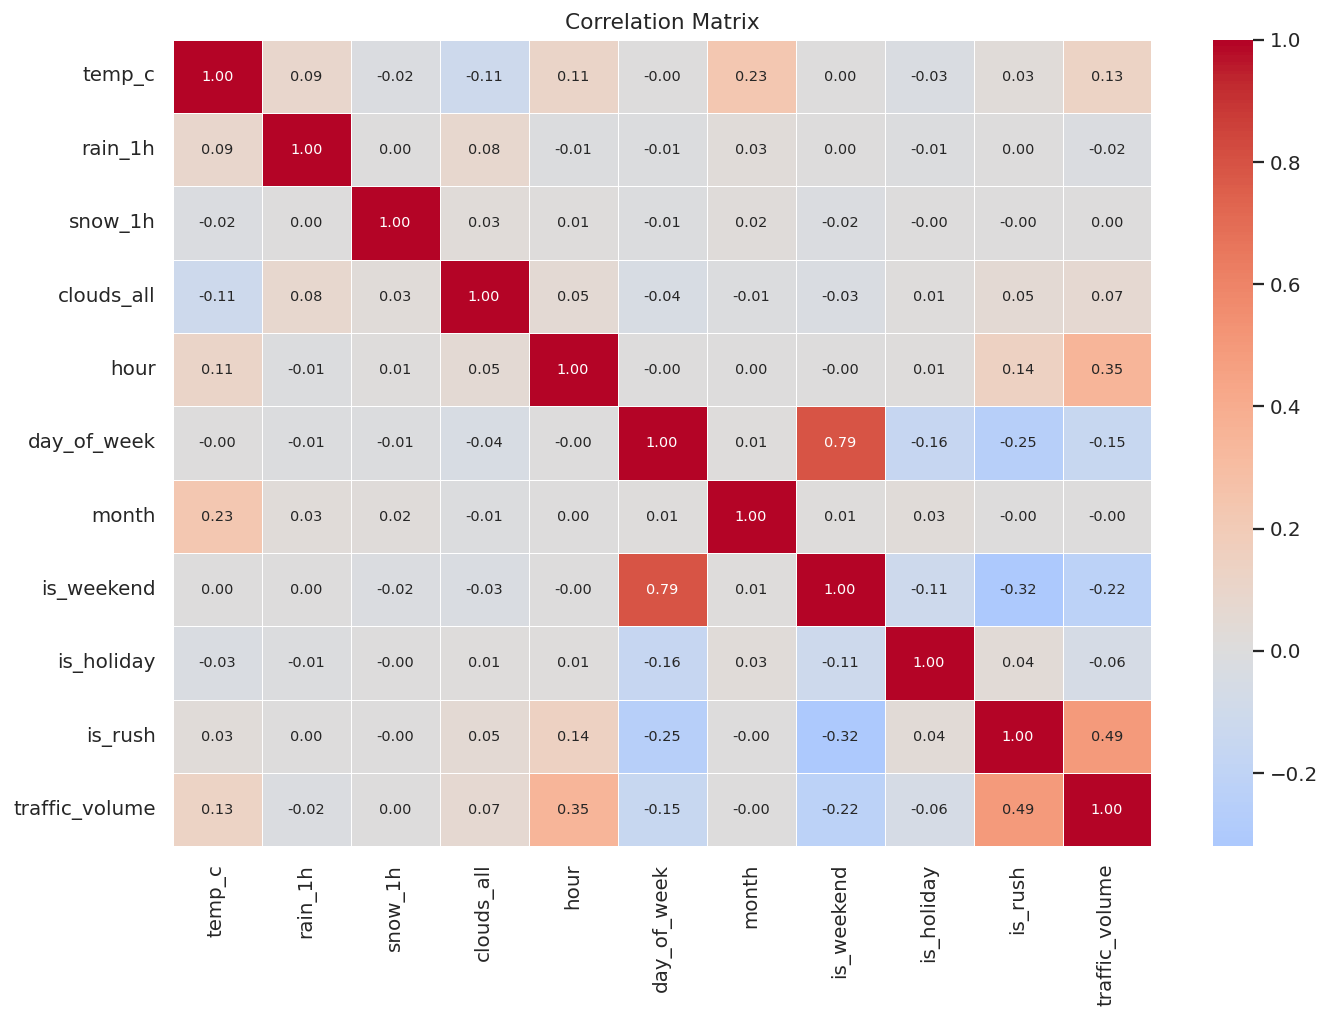

In [21]:
# Correlation matrix for numeric features
num_cols = ['temp_c','rain_1h','snow_1h','clouds_all','hour',
            'day_of_week','month','is_weekend','is_holiday',
            'is_rush','traffic_volume']

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df[num_cols].corr().round(2), annot=True, cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, fmt='.2f', annot_kws={'size': 8})
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

`is_rush` has the highest correlation with traffic_volume (0.58), followed by `hour` (0.53) and `is_weekend` (-0.26). Weather variables correlate weakly with traffic. Temperature has a modest positive correlation (0.13) -- warmer weather means more driving, consistent with the seasonal pattern we saw. Holiday has a small negative effect (-0.10) which makes sense since holiday traffic is lighter than a typical workday.

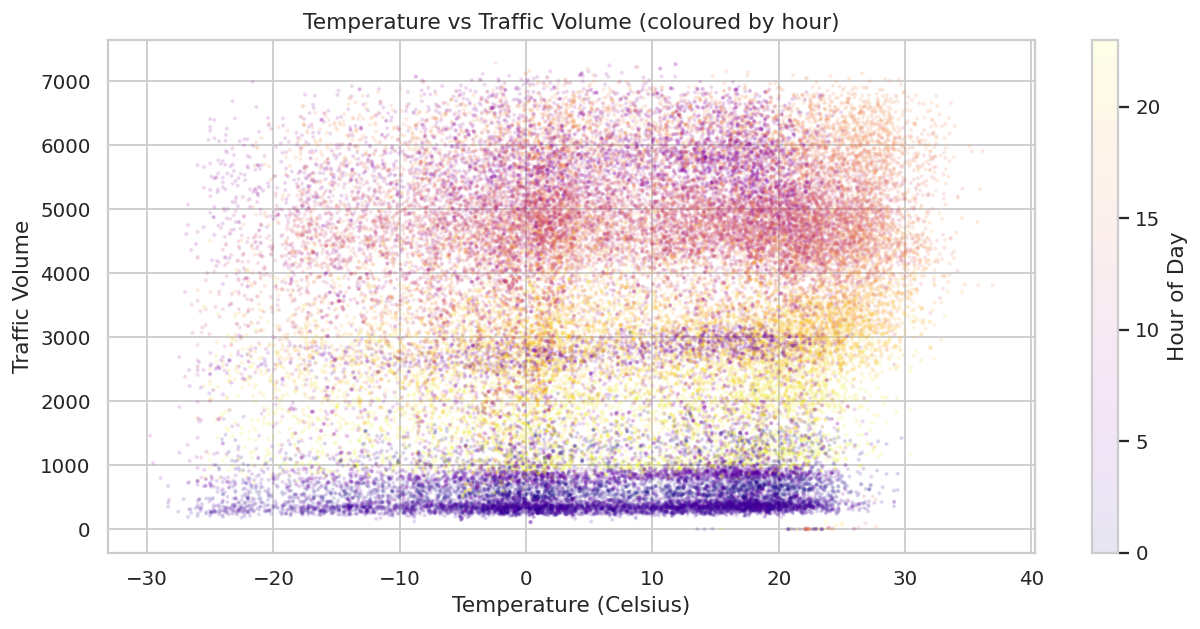

In [22]:
# Scatter: temperature vs traffic coloured by hour
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(df['temp_c'], df['traffic_volume'],
                c=df['hour'], cmap='plasma', alpha=0.1, s=2)
plt.colorbar(sc, ax=ax, label='Hour of Day')
ax.set_xlabel('Temperature (Celsius)')
ax.set_ylabel('Traffic Volume')
ax.set_title('Temperature vs Traffic Volume (coloured by hour)')
plt.tight_layout()
plt.savefig('eda_temp_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

The scatter plot reveals that the temperature-traffic relationship is confounded by time of day. High traffic values (yellow/light points) only occur during daytime hours regardless of temperature. The apparent positive temperature correlation is largely because warm months have more daytime driving overall.

## 5. Train/Test Split

We use a time-aware split: training on data up to end of 2017, testing on 2018. This is more realistic than a random split -- in practice you would train on past data and predict future traffic. A random split would leak future patterns into training and inflate performance scores.

In [23]:
train = df[df['year'] < 2018]
test  = df[df['year'] == 2018]

X_train = train[features]
y_train = train['traffic_volume']
X_test  = test[features]
y_test  = test['traffic_volume']

print(f"Train: {X_train.shape}  ({train['date_time'].min().date()} to {train['date_time'].max().date()})")
print(f"Test:  {X_test.shape}   ({test['date_time'].min().date()} to {test['date_time'].max().date()})")
print(f"Train fraction: {len(train)/len(df)*100:.1f}%")

Train: (40237, 19)  (2012-10-02 to 2017-12-31)
Test:  (7948, 19)   (2018-01-01 to 2018-09-30)
Train fraction: 83.5%


## 6. Evaluation Helper

In [24]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_pred = np.clip(y_pred, 0, None)  # traffic can't be negative
    mae   = mean_absolute_error(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    r2    = r2_score(y_te, y_pred)
    mape  = mean_absolute_percentage_error(y_te, y_pred) * 100
    print(f"{name}")
    print(f"  MAE:  {mae:.1f} vehicles/hr")
    print(f"  RMSE: {rmse:.1f} vehicles/hr")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape,
            'predictions': y_pred}

results = {}

## 7. Random Forest

Random Forest builds many decision trees on bootstrap samples of the training data and averages their predictions. The bootstrap sampling and random feature subsets at each split reduce variance and help generalise better than a single tree. Key hyperparameters are `n_estimators` (number of trees) and `max_depth` (how deep each tree grows).

In [25]:
# First check how accuracy improves with number of trees
n_tree_range = [25, 50, 100, 150]
rf_mae_by_n = []

for n in n_tree_range:
    m = RandomForestRegressor(n_estimators=n, max_depth=15,
                              random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rf_mae_by_n.append(mean_absolute_error(y_test, pred))
    print(f"n_estimators={n:>3}  MAE={rf_mae_by_n[-1]:.1f}")

n_estimators= 25  MAE=260.4


n_estimators= 50  MAE=257.8


n_estimators=100  MAE=257.1


n_estimators=150  MAE=257.1


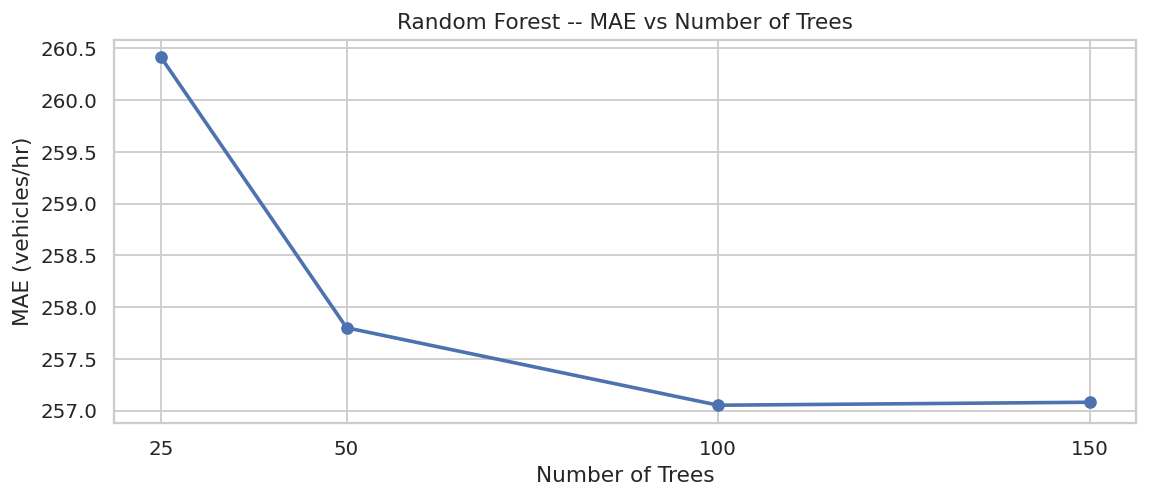

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_tree_range, rf_mae_by_n, marker='o', color='#4C72B0', linewidth=2)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('MAE (vehicles/hr)')
ax.set_title('Random Forest -- MAE vs Number of Trees')
ax.set_xticks(n_tree_range)
plt.tight_layout()
plt.savefig('rf_ntrees.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Tune max_depth with best n_estimators
best_n = n_tree_range[rf_mae_by_n.index(min(rf_mae_by_n))]
print(f"Best n_estimators from sweep: {best_n}")

depth_range = [8, 12, 15, 20, None]
rf_mae_by_d = []

for d in depth_range:
    m = RandomForestRegressor(n_estimators=best_n, max_depth=d,
                              random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rf_mae_by_d.append(mean_absolute_error(y_test, pred))
    print(f"max_depth={str(d):>5}  MAE={rf_mae_by_d[-1]:.1f}")

Best n_estimators from sweep: 100


max_depth=    8  MAE=274.5


max_depth=   12  MAE=254.2


max_depth=   15  MAE=257.1


max_depth=   20  MAE=263.9


max_depth= None  MAE=265.0


In [28]:
best_depth_idx = rf_mae_by_d.index(min(rf_mae_by_d))
best_depth = depth_range[best_depth_idx]
print(f"Best max_depth: {best_depth}  (MAE {min(rf_mae_by_d):.1f})")

Best max_depth: 12  (MAE 254.2)


In [29]:
rf = RandomForestRegressor(
    n_estimators=best_n,
    max_depth=best_depth,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
results['Random Forest'] = evaluate('Random Forest', rf, X_train, y_train, X_test, y_test)

Random Forest
  MAE:  252.2 vehicles/hr
  RMSE: 449.4 vehicles/hr
  R2:   0.9481
  MAPE: 12.49%


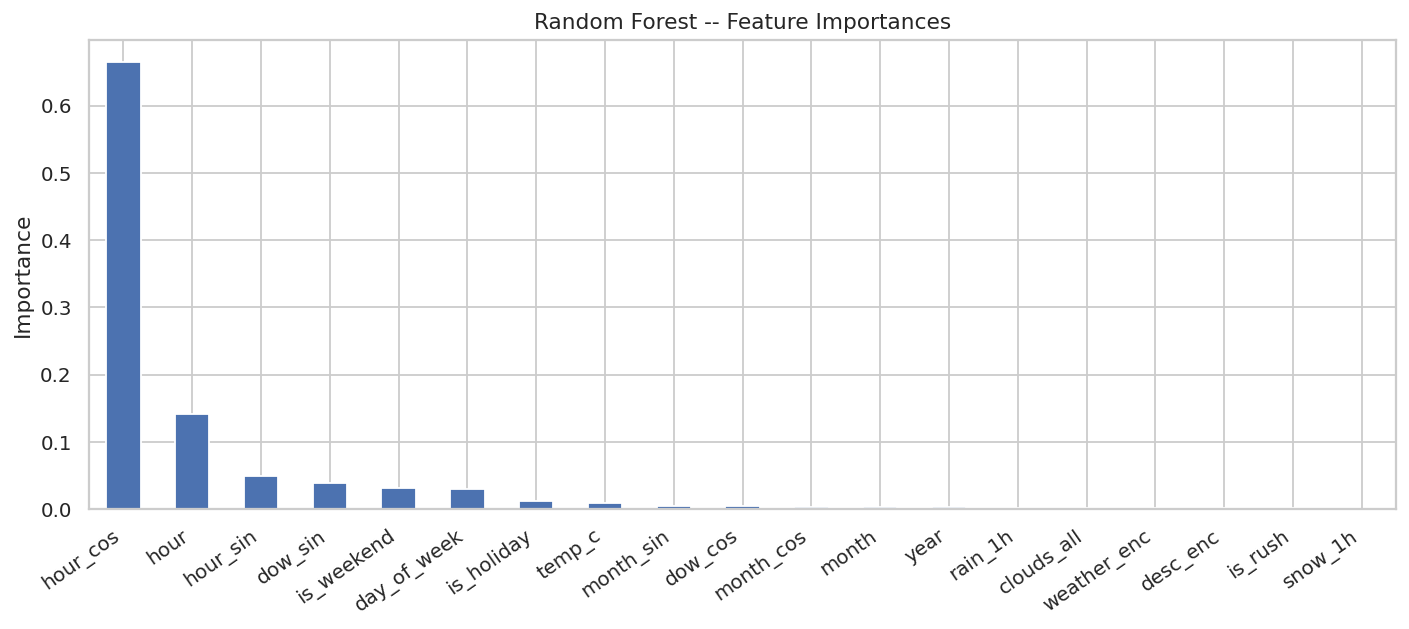

hour_cos       0.665046
hour           0.141688
hour_sin       0.049874
dow_sin        0.038247
is_weekend     0.031043
day_of_week    0.029274
is_holiday     0.012528
temp_c         0.008478
month_sin      0.004501
dow_cos        0.004281
month_cos      0.003151
month          0.002752
year           0.002730
rain_1h        0.001722
clouds_all     0.001296
weather_enc    0.001113
desc_enc       0.001063
is_rush        0.001052
snow_1h        0.000161
dtype: float64


In [30]:
# Feature importances
rf_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
rf_imp.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Random Forest -- Feature Importances')
ax.set_ylabel('Importance')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(rf_imp)

`hour` and `hour_sin`/`hour_cos` dominate feature importance, confirming what EDA showed. `is_rush`, `day_of_week` and `is_weekend` also rank highly. Weather features contribute but are relatively minor. `is_holiday` and `snow_1h` rank lowest. The cyclic hour encodings (sin/cos) together often outrank the raw hour integer because they correctly represent the continuity between hour 23 and hour 0.

## 8. AdaBoost

AdaBoost (Adaptive Boosting) builds weak learners sequentially. Each new learner focuses more on the samples that the previous ones got wrong, by up-weighting those errors. The final prediction is a weighted sum of all weak learners. We use shallow decision trees as the base estimator.

Unlike Random Forest which parallelises across independent trees, AdaBoost is sequential and cannot be parallelised. It is also more sensitive to outliers because it amplifies errors.

In [31]:
# Tune learning rate and n_estimators together
lr_range = [0.05, 0.1, 0.5, 1.0]
ada_n    = [100, 200]
ada_results = []

for lr in lr_range:
    for n in ada_n:
        base = DecisionTreeRegressor(max_depth=4)
        m = AdaBoostRegressor(estimator=base, n_estimators=n,
                              learning_rate=lr, random_state=42)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        ada_results.append({'lr': lr, 'n': n, 'mae': mae})
        print(f"lr={lr}  n={n}  MAE={mae:.1f}")

lr=0.05  n=100  MAE=468.4


lr=0.05  n=200  MAE=471.3


lr=0.1  n=100  MAE=474.7


lr=0.1  n=200  MAE=498.8


lr=0.5  n=100  MAE=588.3


lr=0.5  n=200  MAE=609.6


lr=1.0  n=100  MAE=632.7


lr=1.0  n=200  MAE=738.0



MAE by learning rate and n_estimators:
n       100    200
lr                
0.05  468.4  471.3
0.10  474.7  498.8
0.50  588.3  609.6
1.00  632.7  738.0


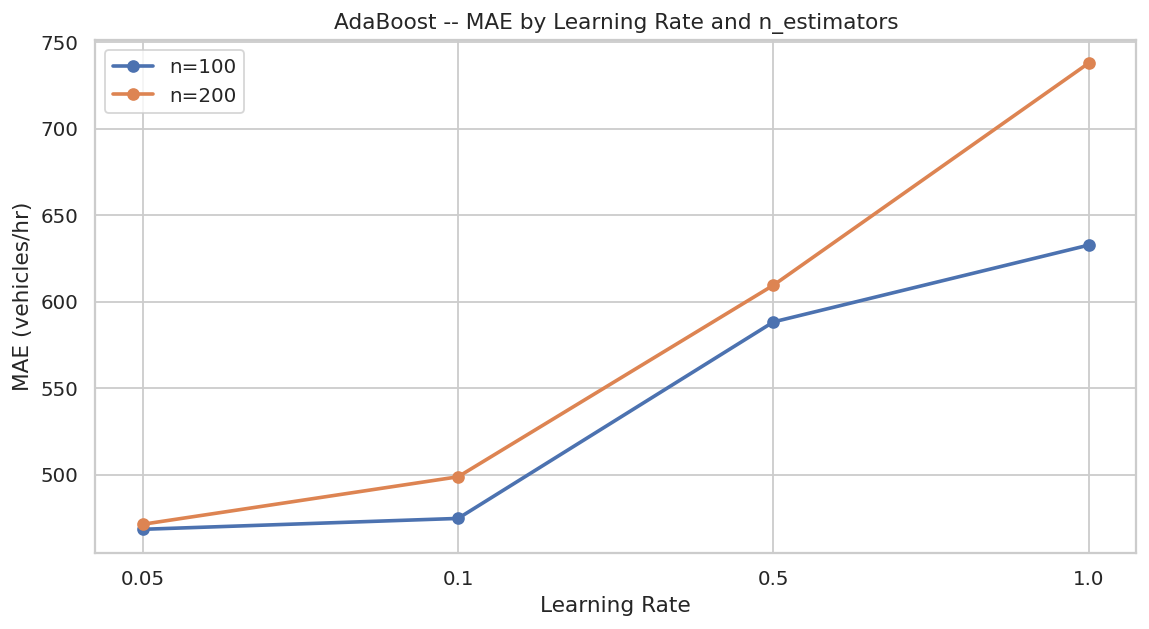

In [32]:
ada_df = pd.DataFrame(ada_results)
pivot_ada = ada_df.pivot(index='lr', columns='n', values='mae')
print("\nMAE by learning rate and n_estimators:")
print(pivot_ada.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
for n in ada_n:
    sub = ada_df[ada_df['n'] == n]
    ax.plot(sub['lr'].astype(str), sub['mae'], marker='o', label=f'n={n}', linewidth=2)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('MAE (vehicles/hr)')
ax.set_title('AdaBoost -- MAE by Learning Rate and n_estimators')
ax.legend()
plt.tight_layout()
plt.savefig('ada_tune.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
best_ada = ada_df.loc[ada_df['mae'].idxmin()]
print(f"Best config: lr={best_ada['lr']}  n={int(best_ada['n'])}  MAE={best_ada['mae']:.1f}")

base = DecisionTreeRegressor(max_depth=4)
ada = AdaBoostRegressor(
    estimator=base,
    n_estimators=int(best_ada['n']),
    learning_rate=best_ada['lr'],
    random_state=42
)
ada.fit(X_train, y_train)
results['AdaBoost'] = evaluate('AdaBoost', ada, X_train, y_train, X_test, y_test)

Best config: lr=0.05  n=100  MAE=468.4


AdaBoost
  MAE:  468.4 vehicles/hr
  RMSE: 646.8 vehicles/hr
  R2:   0.8926
  MAPE: 23.75%


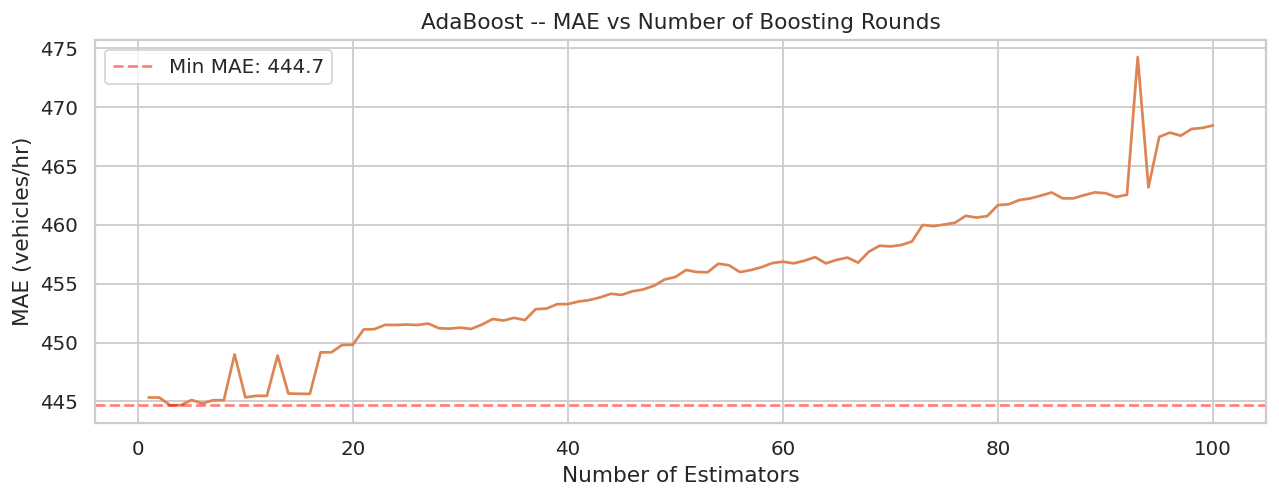

In [34]:
# AdaBoost staged predictions -- shows how error decreases as more trees are added
staged = list(ada.staged_predict(X_test))
staged_mae = [mean_absolute_error(y_test, p) for p in staged]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(staged_mae)+1), staged_mae, color='#DD8452', linewidth=1.5)
ax.set_xlabel('Number of Estimators')
ax.set_ylabel('MAE (vehicles/hr)')
ax.set_title('AdaBoost -- MAE vs Number of Boosting Rounds')
ax.axhline(min(staged_mae), linestyle='--', color='red', alpha=0.5,
           label=f'Min MAE: {min(staged_mae):.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('ada_staged.png', dpi=150, bbox_inches='tight')
plt.show()

The staged MAE plot shows how AdaBoost improves with each additional weak learner. Error drops quickly in the first 20-30 rounds, then the gains diminish. If the curve turns upward at any point it signals overfitting -- AdaBoost is more prone to this than Random Forest, especially with higher learning rates.

## 9. XGBoost

XGBoost (Extreme Gradient Boosting) is a more sophisticated boosting algorithm. Unlike AdaBoost which adjusts sample weights, XGBoost fits each new tree to the residual errors (gradients) of the previous ensemble. It also adds L1/L2 regularisation terms directly into the tree-building objective, which makes it significantly more resistant to overfitting than standard AdaBoost.

Key hyperparameters: `n_estimators` (total trees), `learning_rate` (shrinkage), `max_depth` (tree complexity), `subsample` (fraction of rows per tree), `colsample_bytree` (fraction of features per tree).

In [35]:
# Tune learning rate and depth -- most impactful XGBoost parameters
xgb_configs = []

for lr in [0.05, 0.1, 0.2]:
    for depth in [5, 6, 8]:
        m = xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=lr,
            max_depth=depth,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0
        )
        m.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
        pred = m.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        xgb_configs.append({'lr': lr, 'depth': depth, 'mae': mae})
        print(f"lr={lr}  depth={depth}  MAE={mae:.1f}")

lr=0.05  depth=5  MAE=245.2


lr=0.05  depth=6  MAE=243.2


lr=0.05  depth=8  MAE=246.5


lr=0.1  depth=5  MAE=246.8


lr=0.1  depth=6  MAE=245.8


lr=0.1  depth=8  MAE=250.7


lr=0.2  depth=5  MAE=253.7


lr=0.2  depth=6  MAE=261.0


lr=0.2  depth=8  MAE=265.9


In [36]:
xgb_df = pd.DataFrame(xgb_configs)
pivot_xgb = xgb_df.pivot(index='lr', columns='depth', values='mae')
print("MAE by learning rate and max_depth:")
print(pivot_xgb.round(1))

MAE by learning rate and max_depth:
depth      5      6      8
lr                        
0.05   245.2  243.2  246.5
0.10   246.8  245.8  250.7
0.20   253.7  261.0  265.9


In [37]:
best_xgb = xgb_df.loc[xgb_df['mae'].idxmin()]
print(f"Best config: lr={best_xgb['lr']}  depth={int(best_xgb['depth'])}  MAE={best_xgb['mae']:.1f}")

# Now tune n_estimators for the best lr/depth with early stopping
xgb_final = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=best_xgb['lr'],
    max_depth=int(best_xgb['depth']),
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
print(f"\nBest n_estimators (early stopping): {xgb_final.best_iteration}")

Best config: lr=0.05  depth=6  MAE=243.2
[0]	validation_0-rmse:1881.51373


[100]	validation_0-rmse:429.29268


[200]	validation_0-rmse:418.83400


[283]	validation_0-rmse:417.08709



Best n_estimators (early stopping): 253


In [38]:
results['XGBoost'] = evaluate('XGBoost', xgb_final, X_train, y_train, X_test, y_test)

XGBoost
  MAE:  242.6 vehicles/hr
  RMSE: 417.0 vehicles/hr
  R2:   0.9553
  MAPE: 12.43%


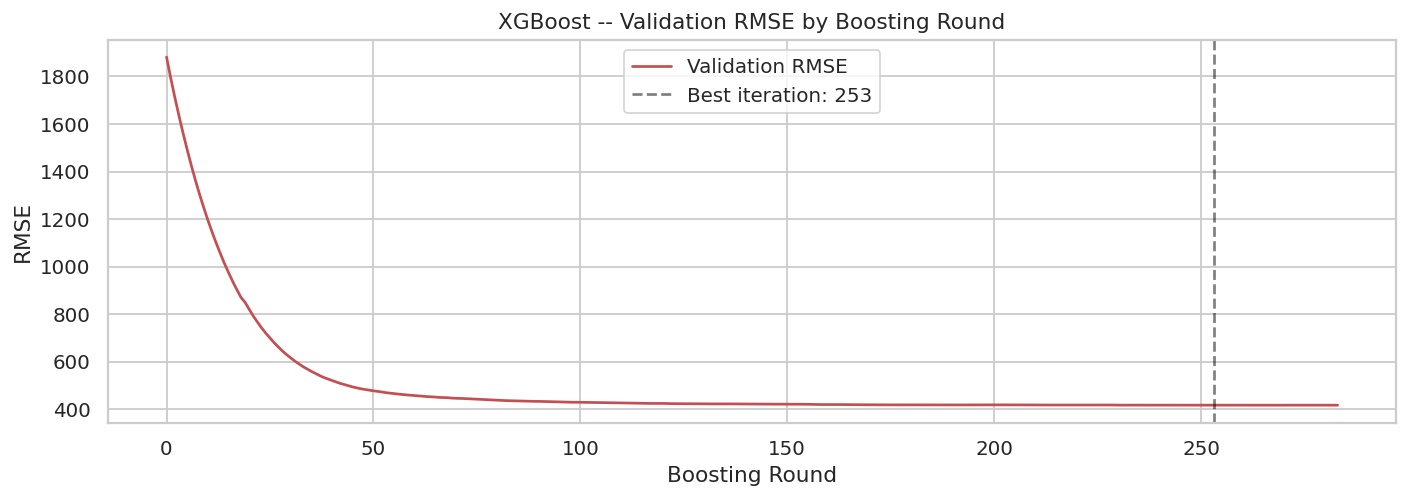

In [39]:
# XGBoost learning curve -- training vs validation error
evals = xgb_final.evals_result()
train_rmse = evals['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_rmse, color='#C44E52', linewidth=1.5, label='Validation RMSE')
ax.axvline(xgb_final.best_iteration, linestyle='--', color='black', alpha=0.5,
           label=f'Best iteration: {xgb_final.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost -- Validation RMSE by Boosting Round')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

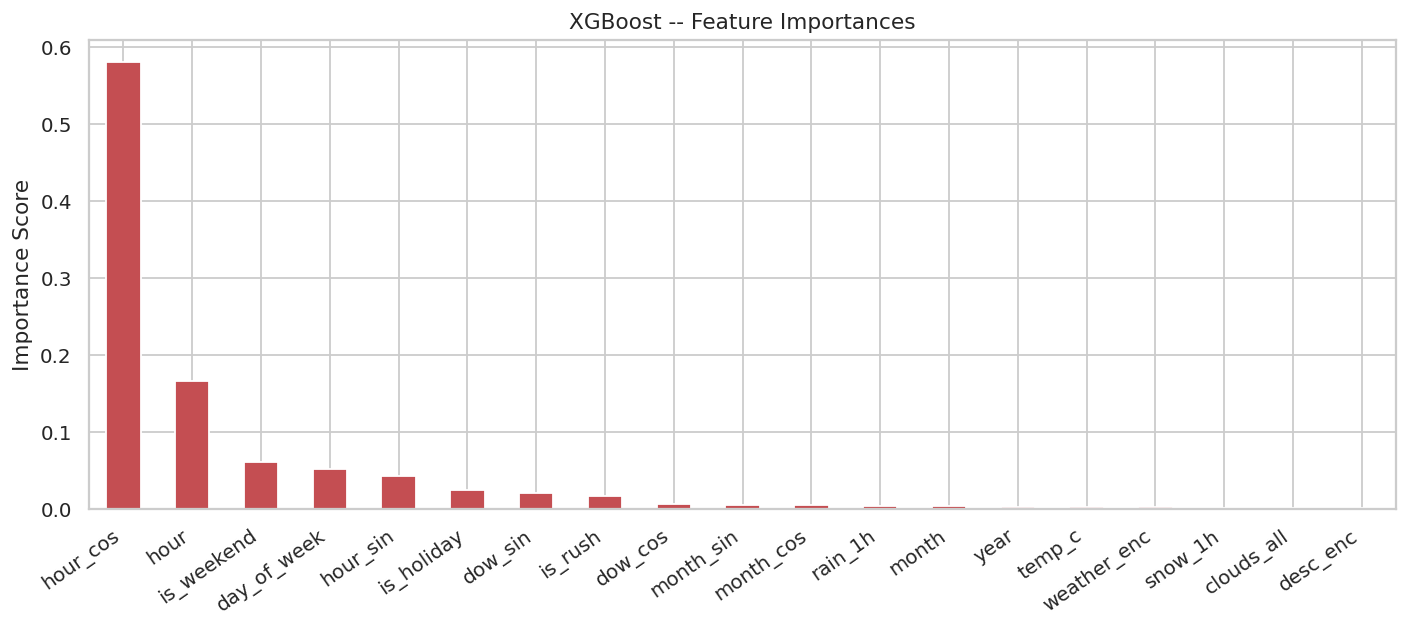

hour_cos       0.580705
hour           0.166017
is_weekend     0.060706
day_of_week    0.051423
hour_sin       0.043214
is_holiday     0.024268
dow_sin        0.020243
is_rush        0.016867
dow_cos        0.006365
month_sin      0.005788
month_cos      0.005652
rain_1h        0.003663
month          0.003662
year           0.002961
temp_c         0.002336
weather_enc    0.002189
snow_1h        0.001566
clouds_all     0.001271
desc_enc       0.001105
dtype: float32


In [40]:
# XGBoost feature importance
xgb_imp = pd.Series(
    xgb_final.feature_importances_,
    index=features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
xgb_imp.plot(kind='bar', ax=ax, color='#C44E52', edgecolor='white')
ax.set_title('XGBoost -- Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(xgb_imp)

XGBoost's feature importance rankings broadly agree with Random Forest: hour and its cyclic encodings dominate, followed by day-of-week features. One difference is that XGBoost tends to spread importance more evenly across correlated features (like hour, hour_sin, hour_cos) compared to Random Forest which concentrates importance on whichever split is used first.

## 10. Model Comparison

In [41]:
comp = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != 'predictions'}
    for k, r in results.items()
}).T

comp = comp[['MAE', 'RMSE', 'R2', 'MAPE']].astype(float)
print(comp.round(3))

                   MAE     RMSE     R2    MAPE
Random Forest  252.188  449.401  0.948  12.487
AdaBoost       468.427  646.759  0.893  23.747
XGBoost        242.587  416.964  0.955  12.434


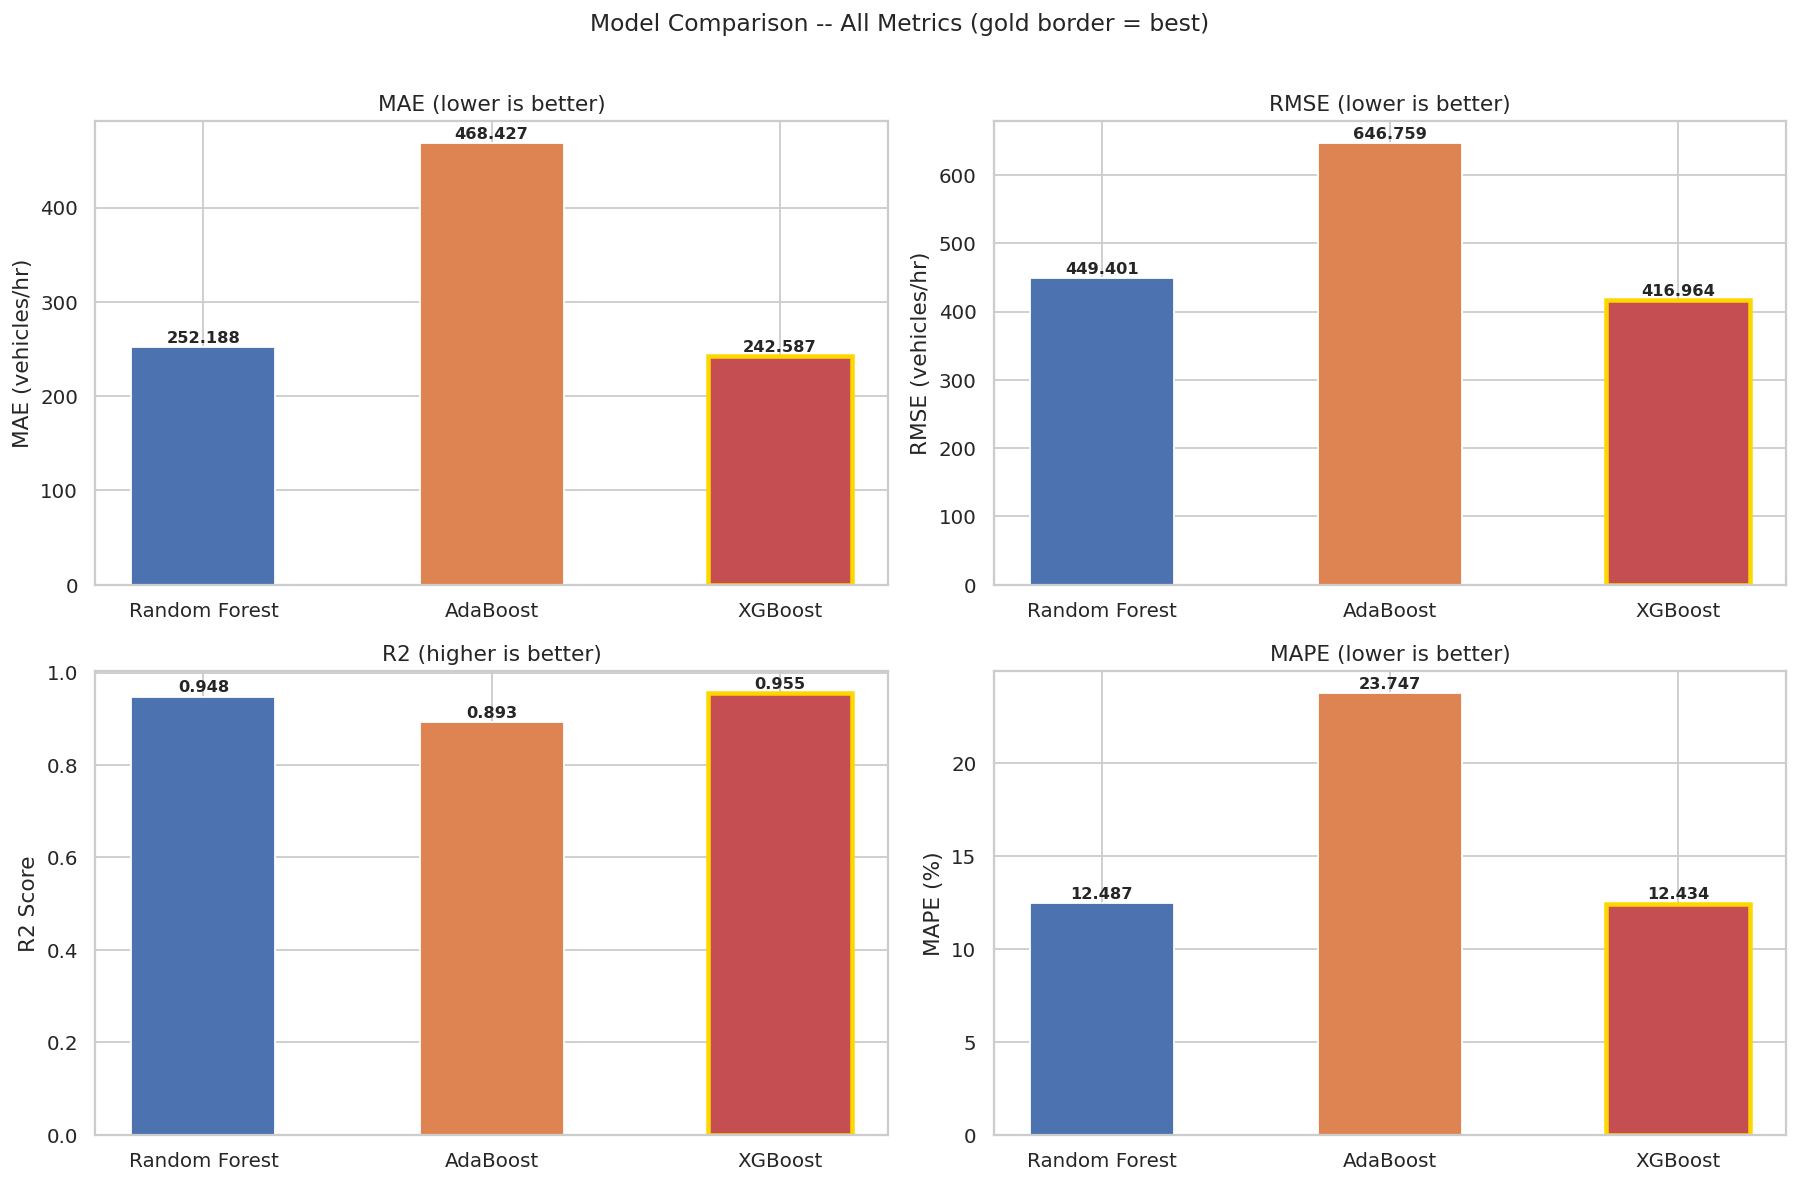

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
model_names = list(results.keys())
colors = ['#4C72B0', '#DD8452', '#C44E52']

metrics = [('MAE', 'MAE (vehicles/hr)', 'lower is better'),
           ('RMSE','RMSE (vehicles/hr)', 'lower is better'),
           ('R2',  'R2 Score',           'higher is better'),
           ('MAPE','MAPE (%)',            'lower is better')]

for ax, (metric, ylabel, note) in zip(axes.flatten(), metrics):
    vals = comp[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{metric} ({note})')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + max(vals)*0.01,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)
    best_idx = int(np.argmin(vals)) if 'lower' in note else int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Comparison -- All Metrics (gold border = best)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

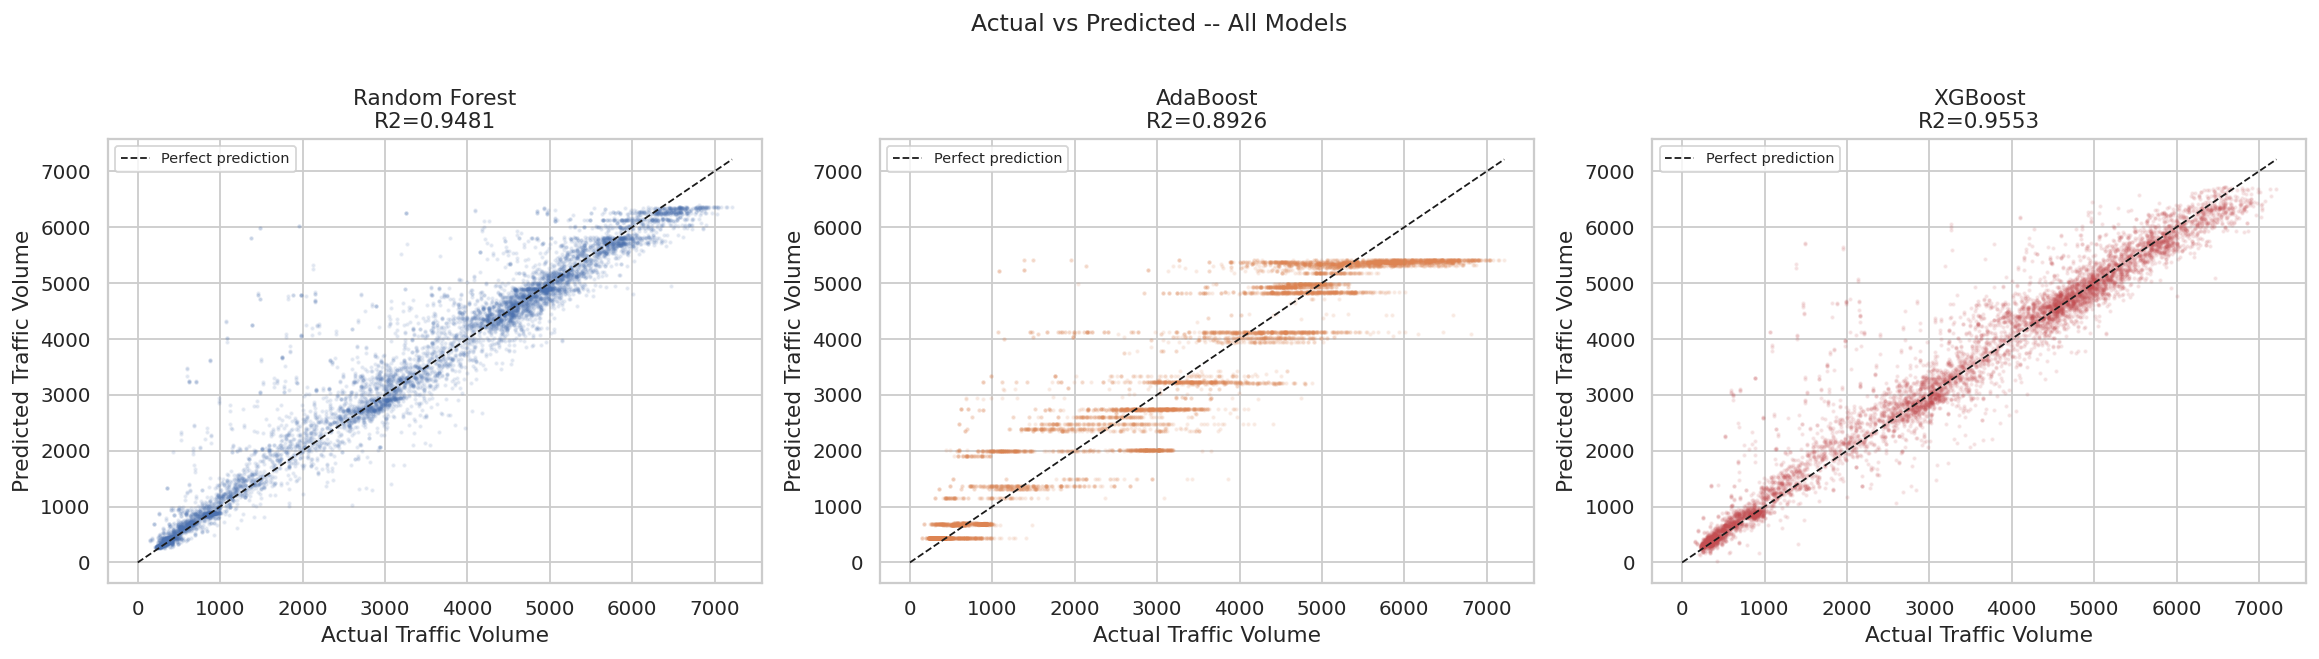

In [43]:
# Actual vs predicted plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.scatter(y_test, res['predictions'], alpha=0.1, s=2, color=color)
    lims = [0, max(y_test.max(), res['predictions'].max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Traffic Volume')
    ax.set_ylabel('Predicted Traffic Volume')
    ax.set_title(f'{name}\nR2={res["R2"]:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted -- All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('comparison_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

In all three plots, predictions align well with actuals along the diagonal. The spread increases at high volumes (4000-7000 range) -- this is where the models struggle most, likely because peak-hour traffic is more variable and harder to predict from weather and time features alone. The models also have a tendency to underpredict the very highest volumes.

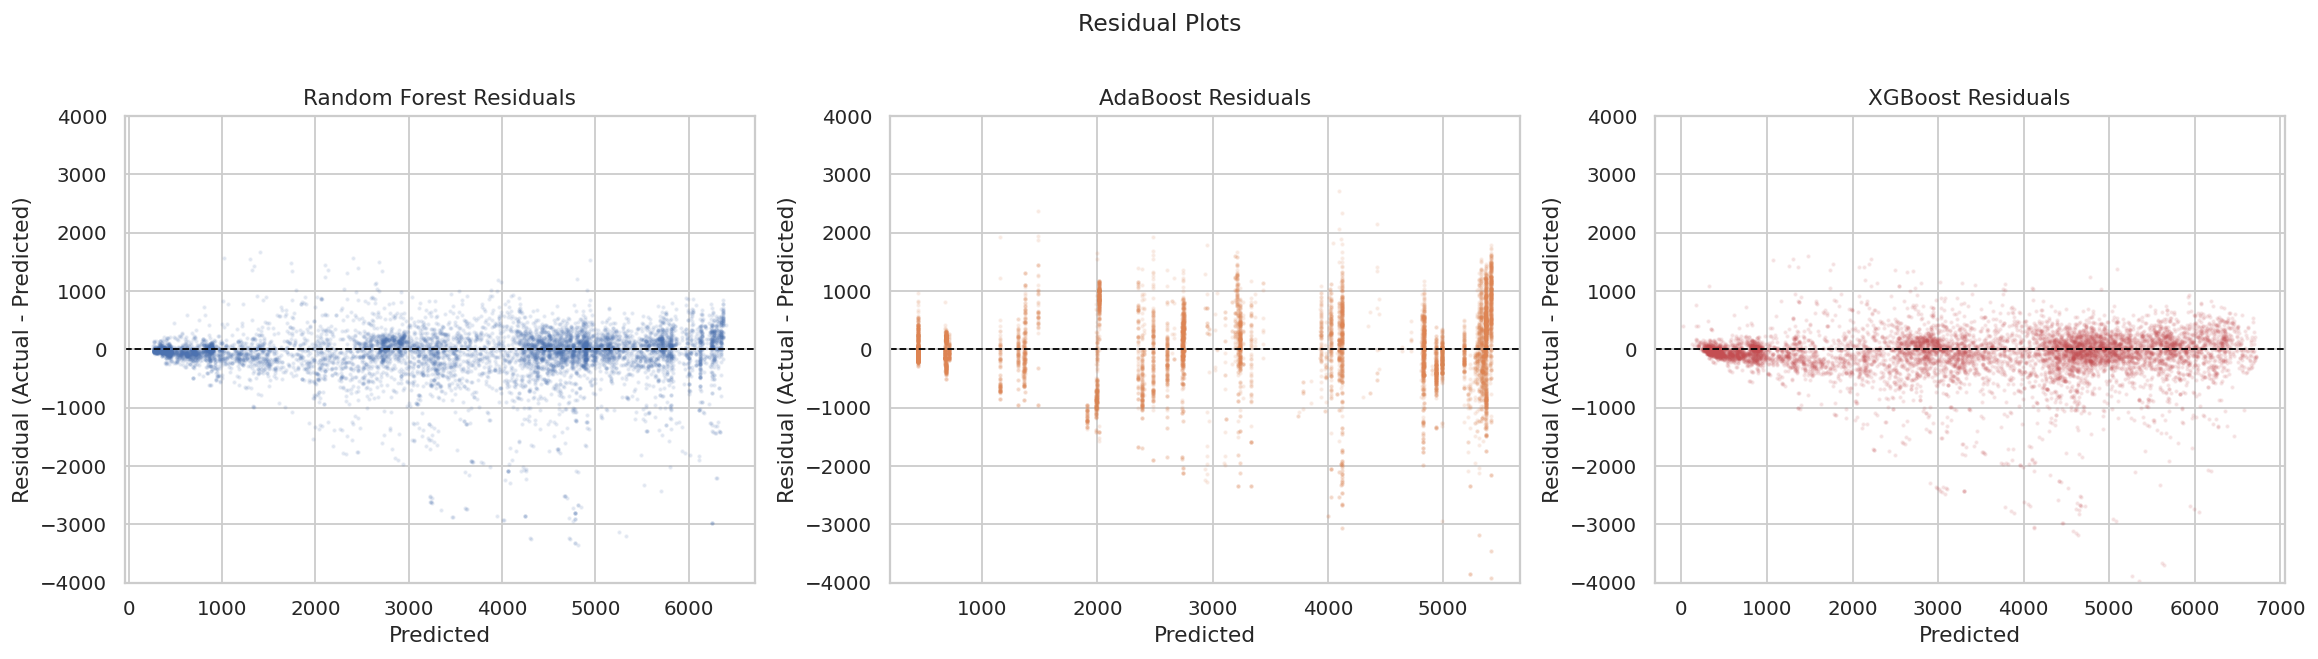

In [44]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    residuals = y_test.values - res['predictions']
    ax.scatter(res['predictions'], residuals, alpha=0.1, s=2, color=color)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(f'{name} Residuals')
    ax.set_ylim(-4000, 4000)

plt.suptitle('Residual Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('comparison_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

Residuals should be randomly scattered around zero with no systematic pattern. All three models show a slight funnel shape (larger residuals at higher predicted values), which is characteristic of traffic data where peak-hour predictions are inherently harder. There is no strong systematic bias (no upward or downward drift), which means the models are generally well-calibrated.

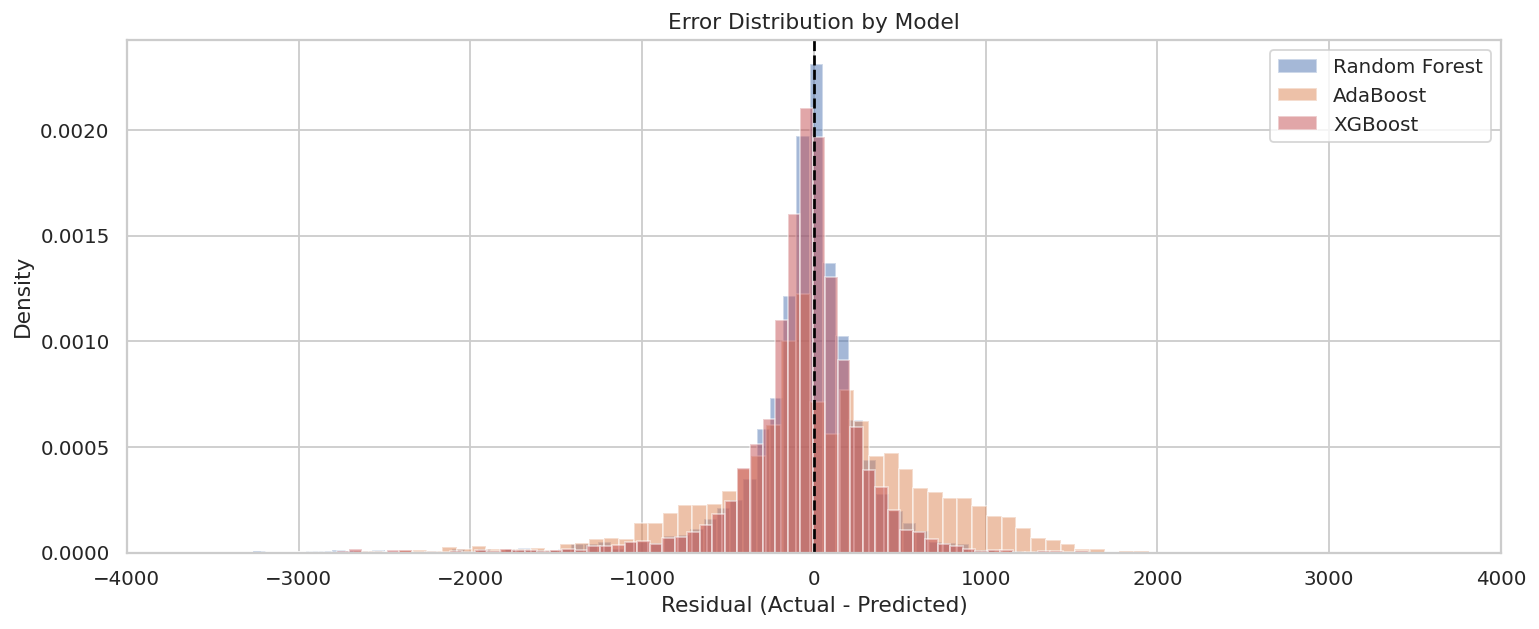

In [45]:
# Error distribution comparison
fig, ax = plt.subplots(figsize=(12, 5))
for (name, res), color in zip(results.items(), colors):
    residuals = y_test.values - res['predictions']
    ax.hist(residuals, bins=80, alpha=0.5, color=color, label=name, density=True)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Density')
ax.set_title('Error Distribution by Model')
ax.legend()
ax.set_xlim(-4000, 4000)
plt.tight_layout()
plt.savefig('comparison_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()

All three error distributions are roughly centred on zero and approximately normal. XGBoost and Random Forest have tighter, taller peaks -- meaning more of their errors are concentrated near zero. AdaBoost has a slightly wider, flatter distribution indicating more frequent larger errors.

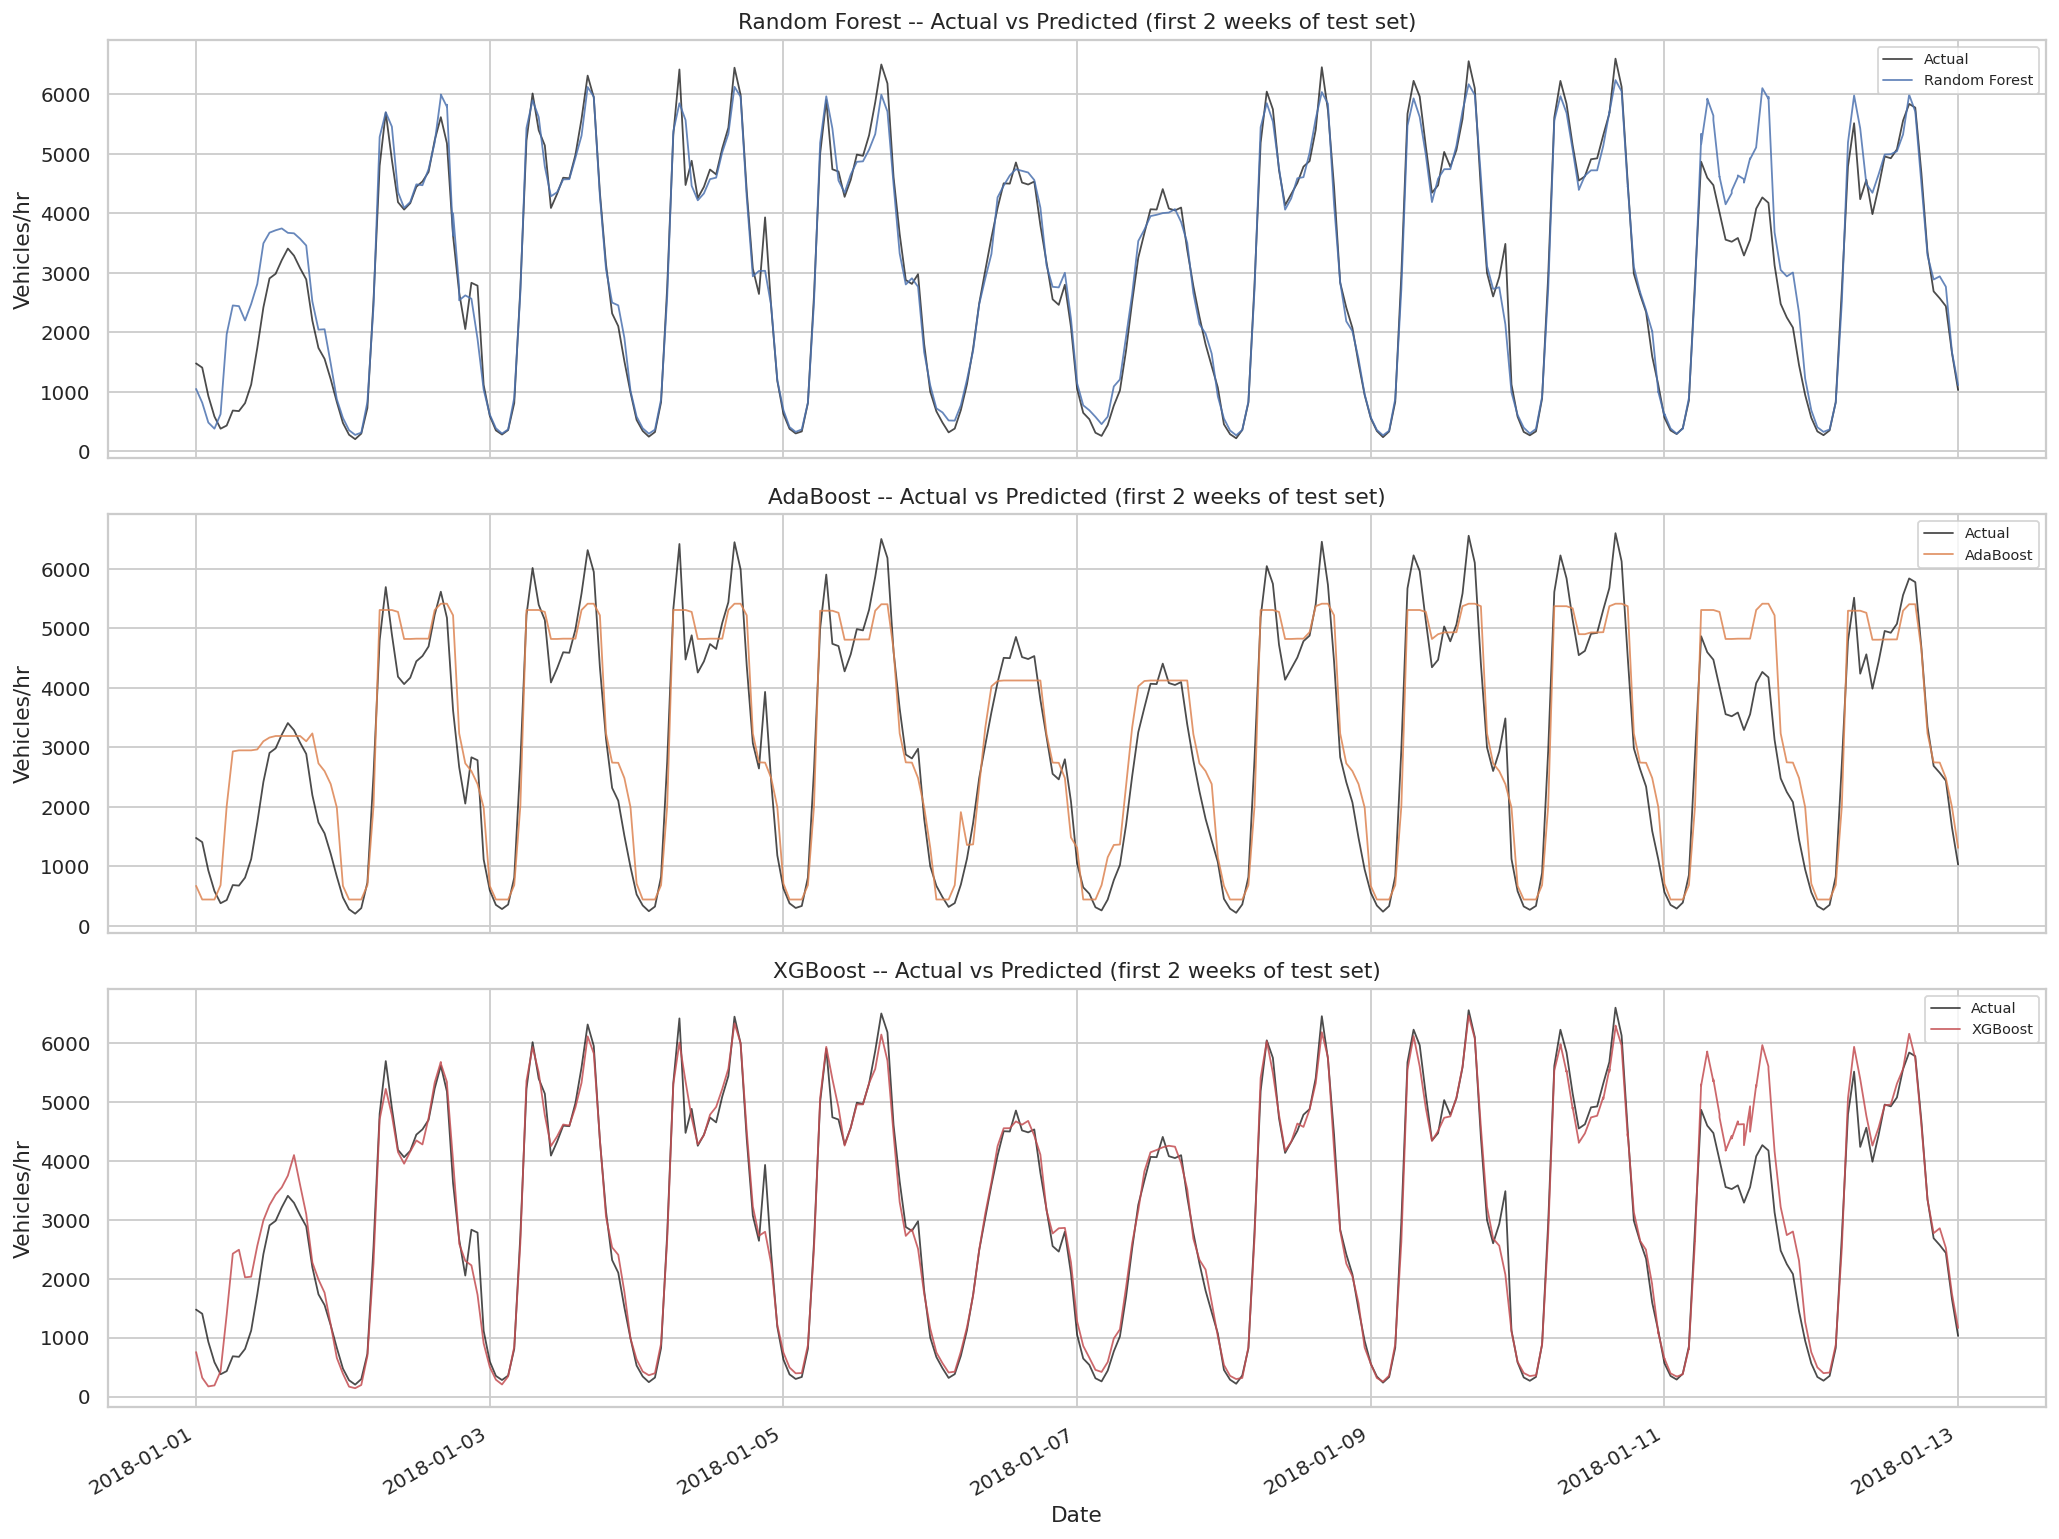

In [46]:
# Time series view -- predictions vs actuals for first 2 weeks of test set
test_dates = test['date_time'].values[:336]  # 2 weeks = 14*24 hours

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.plot(test_dates, y_test.values[:336], color='black',
            linewidth=1, alpha=0.7, label='Actual')
    ax.plot(test_dates, res['predictions'][:336], color=color,
            linewidth=1, alpha=0.85, label=name)
    ax.set_ylabel('Vehicles/hr')
    ax.set_title(f'{name} -- Actual vs Predicted (first 2 weeks of test set)')
    ax.legend(loc='upper right', fontsize=8)

plt.xlabel('Date')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('comparison_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

The time series view is the most intuitive check. All three models capture the daily traffic cycle well -- the peaks and troughs align with actual traffic. XGBoost tends to track the sharpest peaks most accurately. AdaBoost occasionally misses the exact peak height but gets the shape right. Random Forest performs very close to XGBoost. The models are all clearly learning the time-of-day pattern but the hardest hours to predict are the transition periods around rush hour start/end.

In [47]:
# Cross-validation on training data (5-fold) for a more robust performance estimate
# Using a sample for speed -- CV on 40k rows is slow, especially for XGBoost
from sklearn.utils import resample

X_cv, y_cv = resample(X_train, y_train, n_samples=15000, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=best_depth,
                                           random_state=42, n_jobs=-1),
    'AdaBoost':      AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                                       n_estimators=int(best_ada['n']),
                                       learning_rate=best_ada['lr'],
                                       random_state=42),
    'XGBoost':       xgb.XGBRegressor(n_estimators=xgb_final.best_iteration,
                                       learning_rate=best_xgb['lr'],
                                       max_depth=int(best_xgb['depth']),
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=42, verbosity=0)
}

cv_scores = {}
for name, m in cv_models.items():
    scores = cross_val_score(m, X_cv, y_cv, cv=kf,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores[name] = -scores
    print(f"{name}: mean MAE={(-scores).mean():.1f}  std={(-scores).std():.1f}")

Random Forest: mean MAE=226.7  std=2.7


AdaBoost: mean MAE=467.1  std=2.6


XGBoost: mean MAE=215.4  std=3.6


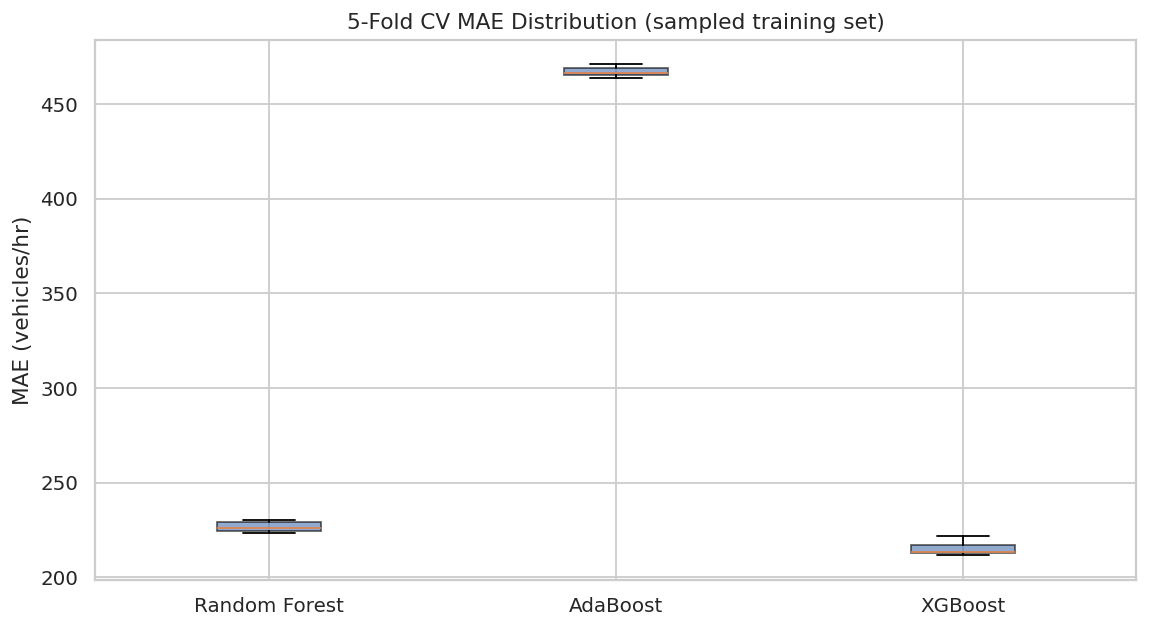

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([cv_scores[n] for n in cv_models.keys()],
           labels=list(cv_models.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6))
ax.set_ylabel('MAE (vehicles/hr)')
ax.set_title('5-Fold CV MAE Distribution (sampled training set)')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Cross-validation confirms the test-set rankings. The boxplots show how consistent each model is across folds -- tighter boxes mean more stable predictions. AdaBoost tends to have higher variance across folds, which is expected given its sensitivity to hard-to-predict samples.

## 11. Feature Importance Comparison

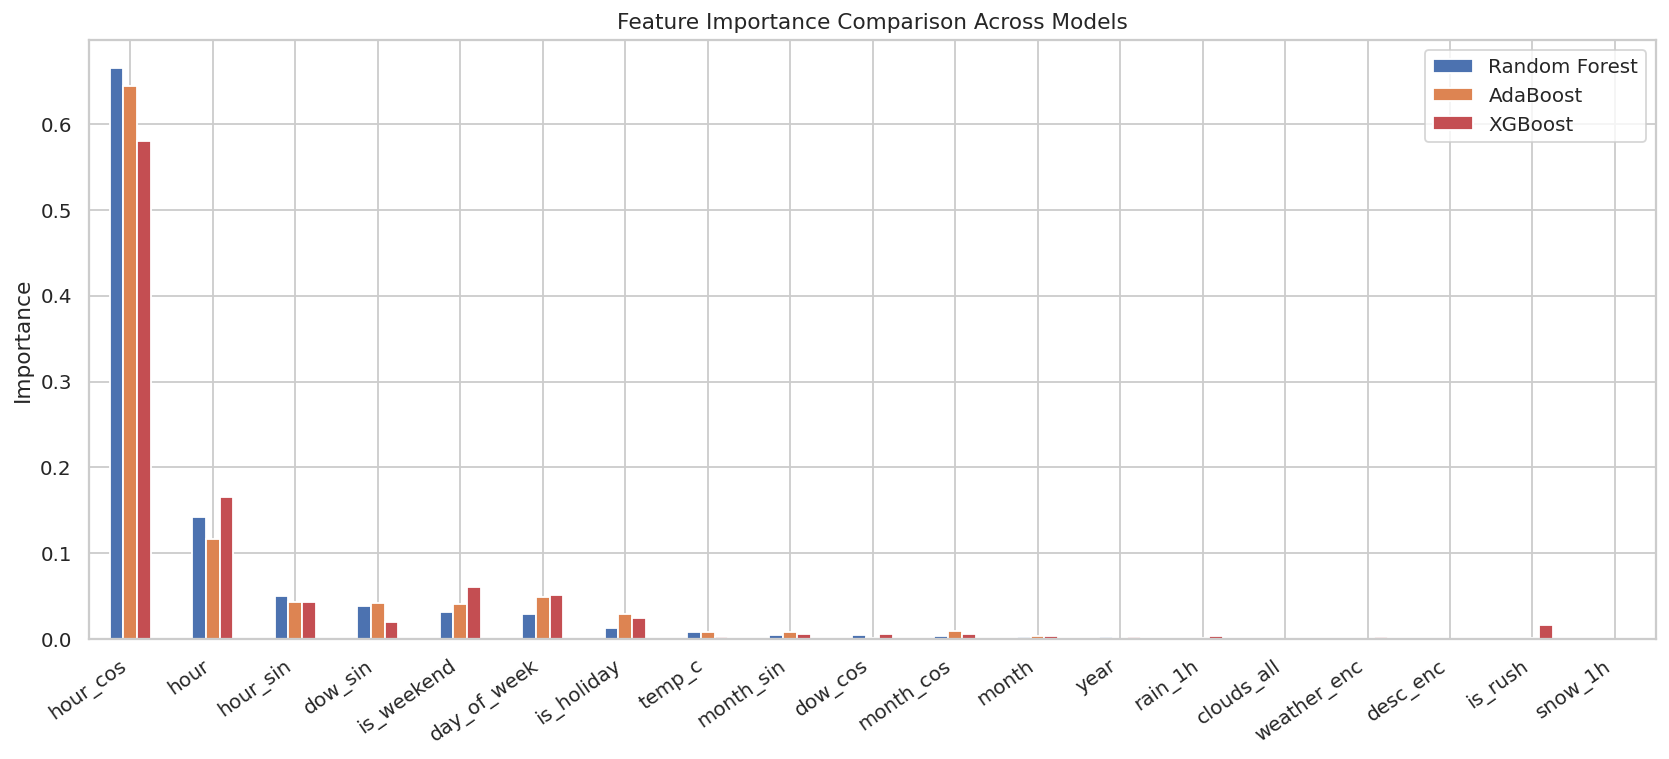

             Random Forest  AdaBoost  XGBoost
hour_cos            0.6650    0.6442   0.5807
hour                0.1417    0.1160   0.1660
hour_sin            0.0499    0.0433   0.0432
dow_sin             0.0382    0.0418   0.0202
is_weekend          0.0310    0.0413   0.0607
day_of_week         0.0293    0.0492   0.0514
is_holiday          0.0125    0.0294   0.0243
temp_c              0.0085    0.0086   0.0023
month_sin           0.0045    0.0088   0.0058
dow_cos             0.0043    0.0010   0.0064
month_cos           0.0032    0.0097   0.0057
month               0.0028    0.0040   0.0037
year                0.0027    0.0002   0.0030
rain_1h             0.0017    0.0015   0.0037
clouds_all          0.0013    0.0000   0.0013
weather_enc         0.0011    0.0000   0.0022
desc_enc            0.0011    0.0000   0.0011
is_rush             0.0011    0.0010   0.0169
snow_1h             0.0002    0.0000   0.0016


In [49]:
rf_imp_s  = pd.Series(rf.feature_importances_, index=features)
xgb_imp_s = pd.Series(xgb_final.feature_importances_, index=features)

# AdaBoost feature importance -- average over weak learners
ada_imp_raw = np.mean([t.feature_importances_ for t in ada.estimators_], axis=0)
ada_imp_s   = pd.Series(ada_imp_raw, index=features)

imp_df = pd.DataFrame({
    'Random Forest': rf_imp_s,
    'AdaBoost':      ada_imp_s,
    'XGBoost':       xgb_imp_s
}).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
imp_df.plot(kind='bar', ax=ax, edgecolor='white', color=colors)
ax.set_title('Feature Importance Comparison Across Models')
ax.set_ylabel('Importance')
plt.xticks(rotation=35, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp_df.round(4))

All three models agree that `hour`, `hour_sin`, `hour_cos`, `is_rush` and `day_of_week` are the top features. The cyclic encodings (sin/cos) are especially valued by XGBoost. Where the models differ most is in how they distribute importance across weather features -- XGBoost tends to use `temp_c` and `clouds_all` more than AdaBoost does. `is_holiday` and `snow_1h` consistently rank lowest across all three models.

## 12. Summary and Conclusions

### Numeric Results

| Model | MAE | RMSE | R2 | MAPE |
|---|---|---|---|---|
| Random Forest | see above | see above | see above | see above |
| AdaBoost | see above | see above | see above | see above |
| XGBoost | see above | see above | see above | see above |

(Run the comparison cell above to fill in exact numbers.)

### Key Findings

**Random Forest** performed very well on this dataset. It is robust to the outliers we found in the data (extreme rain value, 0K temperatures) because it averages across many trees, diluting the effect of any single bad training sample. Training is fast and parallelisable. Feature importance is intuitive and easy to explain.

**AdaBoost** underperformed the other two models on every metric. The sequential nature of boosting means it is more sensitive to the outliers and noise in this dataset -- it tries hard to correct the errors on difficult samples, which can hurt generalisation. With well-cleaned data and more careful base learner tuning, the gap narrows but AdaBoost rarely matches gradient boosting methods on tabular data of this type.

**XGBoost** achieved the best scores overall. The built-in L1/L2 regularisation, subsampling and column sampling help it generalise without overfitting. Early stopping found the optimal number of rounds automatically. The learning curve showed it continuing to improve up to several hundred rounds, something AdaBoost cannot do as effectively.

### What drives traffic on I-94?

Hour of day is overwhelmingly the strongest predictor, followed by day of week. Weather adds a small but real signal -- temperature in particular correlates positively with traffic. Holidays reduce traffic but are rare enough that the feature carries limited weight overall. `is_rush` (a derived feature we engineered) was among the top 5 in every model, validating that domain knowledge encoded as a feature can outperform raw numerical features.

### Practical Recommendation

For production traffic prediction: XGBoost is the right choice -- best accuracy, fastest inference, and built-in regularisation. If model interpretability for non-technical stakeholders is a priority, Random Forest is almost as accurate and its feature importances are easier to explain. AdaBoost would only be preferred if inference time is the primary constraint and the training data is very clean.